In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

In [2]:
BASE_PATH = r"C:\Users\HP\Desktop\GAVE2_preliminary"

TRAIN_IMAGE_DIR = os.path.join(BASE_PATH, "training", "images")
TRAIN_AV_DIR = os.path.join(BASE_PATH, "training", "av")
TRAIN_MASK_DIR = os.path.join(BASE_PATH, "training", "masks")

VAL_IMAGE_DIR = os.path.join(BASE_PATH, "validation", "images")
VAL_MASK_DIR = os.path.join(BASE_PATH, "validation", "masks")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_W = 768
IMG_H = 512

BATCH_SIZE = 1
LR = 1e-4
EPOCHS = 10

print(DEVICE)

cuda


In [3]:
def enhance_fundus(img):
    img = cv2.resize(img, (IMG_W, IMG_H))
    
    img = img.astype(np.float32) / 255.0
    
    r = img[:, :, 0]
    g = img[:, :, 1]
    b = img[:, :, 2]

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    r = clahe.apply((r * 255).astype(np.uint8)) / 255.0
    g = clahe.apply((g * 255).astype(np.uint8)) / 255.0
    b = clahe.apply((b * 255).astype(np.uint8)) / 255.0

    enhanced = np.stack([r, g, b], axis=-1)

    return enhanced.astype(np.float32)

In [4]:
class GAVE2Dataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.image_files = sorted(os.listdir(image_dir))
        self.mask_files = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        img = enhance_fundus(img)
        mask = cv2.resize(mask, (IMG_W, IMG_H), interpolation=cv2.INTER_NEAREST)

        artery = ((mask == 1) | (mask == 2)).astype(np.float32)
        vein = ((mask == 3) | (mask == 2)).astype(np.float32)
        vessel_tree = (mask > 0).astype(np.float32)

        target = np.stack([artery, vein, vessel_tree], axis=0)

        img = torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32)
        target = torch.tensor(target, dtype=torch.float32)

        return img, target

In [5]:
all_images = sorted(os.listdir(TRAIN_IMAGE_DIR))
all_avs = sorted(os.listdir(TRAIN_AV_DIR))
all_masks = sorted(os.listdir(TRAIN_MASK_DIR))

print(len(all_images), len(all_avs), len(all_masks))

indices = list(range(len(all_images)))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=10,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=5,
    random_state=42
)

print("Train:", len(train_idx))
print("Val:", len(val_idx))
print("Test:", len(test_idx))

50 50 50
Train: 40
Val: 5
Test: 5


In [6]:
class GAVE2RRWDataset(Dataset):
    def __init__(self, indices):
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]

        img_path = os.path.join(TRAIN_IMAGE_DIR, all_images[idx])
        av_path = os.path.join(TRAIN_AV_DIR, all_avs[idx])
        roi_path = os.path.join(TRAIN_MASK_DIR, all_masks[idx])

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        av = cv2.imread(av_path)
        av = cv2.cvtColor(av, cv2.COLOR_BGR2RGB)

        roi = cv2.imread(roi_path, cv2.IMREAD_GRAYSCALE)

        img = enhance_fundus(img)

        av = cv2.resize(av, (IMG_W, IMG_H), interpolation=cv2.INTER_NEAREST)
        roi = cv2.resize(roi, (IMG_W, IMG_H), interpolation=cv2.INTER_NEAREST)

        red = np.all(av == [255, 0, 0], axis=-1)
        blue = np.all(av == [0, 0, 255], axis=-1)
        green = np.all(av == [0, 255, 0], axis=-1)

        artery = (red | green).astype(np.float32)
        vein = (blue | green).astype(np.float32)
        vessel_tree = (red | blue | green).astype(np.float32)

        target = np.stack([artery, vein, vessel_tree], axis=0)

        roi = (roi > 0).astype(np.float32)
        roi = np.expand_dims(roi, axis=0)

        img = torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32)
        target = torch.tensor(target, dtype=torch.float32)
        roi = torch.tensor(roi, dtype=torch.float32)

        return img, target, roi

In [7]:
train_dataset = GAVE2RRWDataset(train_idx)
val_dataset = GAVE2RRWDataset(val_idx)
test_dataset = GAVE2RRWDataset(test_idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

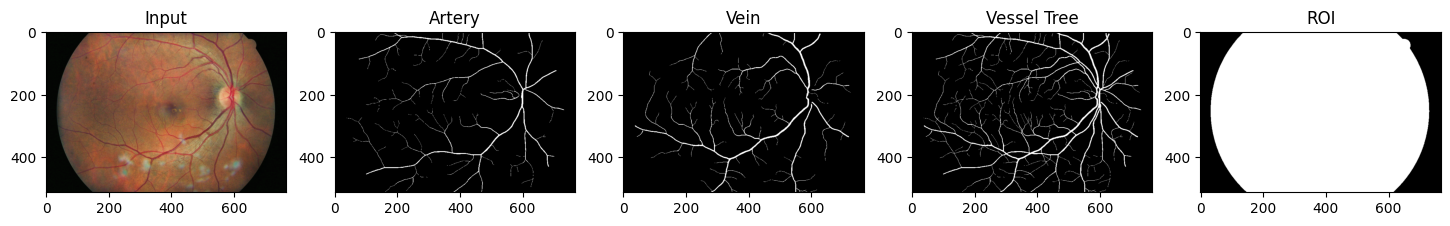

In [8]:
images, targets, rois = next(iter(train_loader))

img = images[0].permute(1,2,0).numpy()
artery = targets[0][0].numpy()
vein = targets[0][1].numpy()
vt = targets[0][2].numpy()
roi = rois[0][0].numpy()

plt.figure(figsize=(18,4))

plt.subplot(1,5,1)
plt.imshow(img)
plt.title("Input")

plt.subplot(1,5,2)
plt.imshow(artery, cmap='gray')
plt.title("Artery")

plt.subplot(1,5,3)
plt.imshow(vein, cmap='gray')
plt.title("Vein")

plt.subplot(1,5,4)
plt.imshow(vt, cmap='gray')
plt.title("Vessel Tree")

plt.subplot(1,5,5)
plt.imshow(roi, cmap='gray')
plt.title("ROI")

plt.show()

In [9]:
class ConvBlock(nn.Module):
    def __init__(self, input_ch=3, output_ch=64):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(input_ch, output_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(output_ch, output_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UpConv(nn.Module):
    def __init__(self, input_ch, output_ch):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            input_ch,
            output_ch,
            kernel_size=2,
            stride=2
        )

    def forward(self, x):
        return self.up(x)


class UNetModule(nn.Module):
    def __init__(self, input_ch, output_ch, base_ch):
        super().__init__()

        self.conv1 = ConvBlock(input_ch, base_ch)
        self.conv2 = ConvBlock(base_ch, base_ch * 2)
        self.conv3 = ConvBlock(base_ch * 2, base_ch * 4)
        self.conv4 = ConvBlock(base_ch * 4, base_ch * 8)
        self.conv5 = ConvBlock(base_ch * 8, base_ch * 16)

        self.up1 = UpConv(base_ch * 16, base_ch * 8)
        self.conv6 = ConvBlock(base_ch * 16, base_ch * 8)

        self.up2 = UpConv(base_ch * 8, base_ch * 4)
        self.conv7 = ConvBlock(base_ch * 8, base_ch * 4)

        self.up3 = UpConv(base_ch * 4, base_ch * 2)
        self.conv8 = ConvBlock(base_ch * 4, base_ch * 2)

        self.up4 = UpConv(base_ch * 2, base_ch)
        self.conv9 = ConvBlock(base_ch * 2, base_ch)

        self.outconv = nn.Conv2d(base_ch, output_ch, kernel_size=1)

    def forward(self, x):
        x1 = self.conv1(x)
        x = F.max_pool2d(x1, 2)

        x2 = self.conv2(x)
        x = F.max_pool2d(x2, 2)

        x3 = self.conv3(x)
        x = F.max_pool2d(x3, 2)

        x4 = self.conv4(x)
        x = F.max_pool2d(x4, 2)

        x = self.conv5(x)

        x = self.up1(x)
        x = torch.cat((x4, x), dim=1)

        x = self.conv6(x)
        x = self.up2(x)
        x = torch.cat((x3, x), dim=1)

        x = self.conv7(x)
        x = self.up3(x)
        x = torch.cat((x2, x), dim=1)

        x = self.conv8(x)
        x = self.up4(x)
        x = torch.cat((x1, x), dim=1)

        x = self.conv9(x)
        x = self.outconv(x)

        return x


class RRWNet(nn.Module):
    def __init__(self, input_ch=3, output_ch=3, base_ch=64, num_iterations=5):
        super().__init__()

        self.first_u = UNetModule(input_ch, output_ch, base_ch)
        self.second_u = UNetModule(output_ch, 2, base_ch)

        self.num_iterations = num_iterations

    def forward(self, x):
        predictions = []

        pred_1 = self.first_u(x)
        predictions.append(pred_1)

        bv_logits = pred_1[:, 2:3, :, :]
        pred_1_sig = torch.sigmoid(pred_1)
        bv = pred_1_sig[:, 2:3, :, :]

        pred_2 = self.second_u(pred_1_sig)
        predictions.append(torch.cat((pred_2, bv_logits), dim=1))

        for _ in range(self.num_iterations):
            pred_2_sig = torch.sigmoid(pred_2)
            pred_2_input = torch.cat((pred_2_sig, bv), dim=1)
            pred_2 = self.second_u(pred_2_input)
            predictions.append(torch.cat((pred_2, bv_logits), dim=1))

        return predictions

In [10]:
class BCE3Loss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, preds, targets, roi):
        roi = roi[:, 0, :, :]

        pred_a = preds[:, 0, :, :]
        pred_v = preds[:, 1, :, :]
        pred_vt = preds[:, 2, :, :]

        gt_a = targets[:, 0, :, :]
        gt_v = targets[:, 1, :, :]
        gt_vt = targets[:, 2, :, :]

        loss_a = self.bce(pred_a[roi > 0], gt_a[roi > 0])
        loss_v = self.bce(pred_v[roi > 0], gt_v[roi > 0])
        loss_vt = self.bce(pred_vt[roi > 0], gt_vt[roi > 0])

        return loss_a + loss_v + loss_vt

In [11]:
class RRLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.base_loss = BCE3Loss()

    def forward(self, predictions, targets, roi):
        loss1 = self.base_loss(predictions[0], targets, roi)

        if len(predictions) == 1:
            return loss1

        refinement_loss = 0

        for i, pred in enumerate(predictions[1:], 1):
            refinement_loss += i * self.base_loss(pred, targets, roi)

        K = len(predictions[1:])
        Z = (K * (K + 1)) / 2

        refinement_loss = refinement_loss / Z

        return loss1 + refinement_loss

In [12]:
def dice_score(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    dice = (2 * intersection + 1e-6) / (union + 1e-6)

    return dice.item()

In [13]:
model = RRWNet(
    input_ch=3,
    output_ch=3,
    base_ch=32,
    num_iterations=5
).to(DEVICE)

criterion = RRLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print(sum(p.numel() for p in model.parameters()) / 1e6, "Million params")

15.520293 Million params


In [14]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    total_dice = 0

    for images, targets, rois in tqdm(loader):
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)
        rois = rois.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, targets, rois)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(outputs[-1], targets)

    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)

    return avg_loss, avg_dice

In [15]:
def validate(model, loader, criterion):
    model.eval()

    total_loss = 0
    total_dice = 0

    with torch.no_grad():
        for images, targets, rois in tqdm(loader):
            images = images.to(DEVICE)
            targets = targets.to(DEVICE)
            rois = rois.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, targets, rois)

            total_loss += loss.item()
            total_dice += dice_score(outputs[-1], targets)

    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)

    return avg_loss, avg_dice

In [16]:
best_val_dice = 0

for epoch in range(EPOCHS):

    train_loss, train_dice = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_dice = validate(
        model, val_loader, criterion
    )

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_rrwnet_true.pth")

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")
    print("="*60)

100%|██████████| 5/5 [00:00<00:00,  7.72it/s]


Epoch 1/10
Train Loss: 4.1495 | Train Dice: 0.0816
Val Loss: 2.7970 | Val Dice: 0.0018


100%|██████████| 5/5 [00:00<00:00,  7.69it/s]


Epoch 2/10
Train Loss: 1.5657 | Train Dice: 0.0001
Val Loss: 1.2344 | Val Dice: 0.0000


100%|██████████| 5/5 [00:00<00:00,  7.67it/s]


...

Epoch 8/10
Train Loss: 1.2226 | Train Dice: 0.0000
Val Loss: 1.1755 | Val Dice: 0.0000


100%|██████████| 5/5 [00:00<00:00,  7.62it/s]


Epoch 9/10
Train Loss: 1.2332 | Train Dice: 0.0000
Val Loss: 1.1586 | Val Dice: 0.0000


100%|██████████| 5/5 [00:00<00:00,  7.59it/s]

Epoch 10/10
Train Loss: 1.2171 | Train Dice: 0.0000
Val Loss: 1.1761 | Val Dice: 0.0000


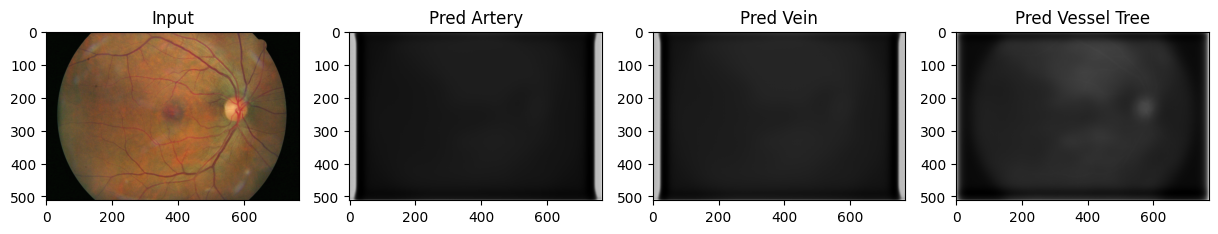

In [17]:
model.eval()

images, targets, rois = next(iter(val_loader))

images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images)

pred = torch.sigmoid(outputs[-1])[0].cpu().numpy()

plt.figure(figsize=(15,4))

plt.subplot(1,4,1)
plt.imshow(images[0].permute(1,2,0).cpu())
plt.title("Input")

plt.subplot(1,4,2)
plt.imshow(pred[0], cmap='gray')
plt.title("Pred Artery")

plt.subplot(1,4,3)
plt.imshow(pred[1], cmap='gray')
plt.title("Pred Vein")

plt.subplot(1,4,4)
plt.imshow(pred[2], cmap='gray')
plt.title("Pred Vessel Tree")

plt.show()